In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
sns.set(style='whitegrid')


In [2]:
#Load Dataset
df = pd.read_csv("drop_prediction.csv")

In [3]:
#Show first 5 rows
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [4]:
#Original columns names
print("Original column names:")
print(df.columns.tolist())

Original column names:
['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department', 'Parental_Education', 'Dropout']


In [5]:
#Clean Column Names
df.columns = df.columns.str.strip()

print("\nColumn names after stripping spaces:")
print(df.columns.tolist())


Column names after stripping spaces:
['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department', 'Parental_Education', 'Dropout']


In [11]:
#Task 1: Identify Data Quality Issues

#Data types ( all in correct format )
print(df.dtypes) 

Data types before conversion:
Student_ID                 int64
Age                      float64
Gender                    object
Family_Income            float64
Internet_Access           object
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job             object
Scholarship               object
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                  object
Department                object
Parental_Education        object
Dropout                    int64
dtype: object


In [12]:
#Missing values (we have some missing values)
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64


In [14]:
#Duplicated rows (no duplicated)
print("\nDuplicate rows:")
print(df.duplicated().sum())


Duplicate rows:
0


In [16]:
#stat summary
print("\nSummary statistics:")
display(df.describe(include='all'))


Summary statistics:


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
count,10000.00000,10000.00000,10000,9500.000000,10000,9500.000000,10000.00000,10000.000000,10000.00000,10000,10000,9500.000000,10000.000000,10000.000000,10000.000000,10000,10000,9489,10000.00000
unique,NaN,NaN,2,NaN,2,NaN,NaN,NaN,NaN,2,2,NaN,NaN,NaN,NaN,4,5,4,NaN
top,NaN,NaN,Female,NaN,Yes,NaN,NaN,NaN,NaN,No,No,NaN,NaN,NaN,NaN,Year 4,Science,Bachelor,NaN
freq,NaN,NaN,5011,NaN,8769,NaN,NaN,NaN,NaN,5996,6489,NaN,NaN,NaN,NaN,2536,2061,3949,NaN
mean,5000.50000,21.02606,NaN,38377.247474,NaN,4.014592,81.73683,1.799700,30.17926,NaN,NaN,5.507147,2.308440,2.300057,2.298761,NaN,NaN,NaN,0.23540
std,2886.89568,2.13981,NaN,20496.232179,NaN,1.295450,8.22093,1.344307,11.91887,NaN,NaN,1.765951,1.061717,1.074407,1.072555,NaN,NaN,NaN,0.42427
min,1.00000,17.00000,NaN,25000.000000,NaN,0.500000,38.20000,0.000000,5.00000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.00000
25%,2500.75000,19.50000,NaN,25000.000000,NaN,3.160000,76.40000,1.000000,21.90000,NaN,NaN,4.300000,1.550000,1.520000,1.520000,NaN,NaN,NaN,0.00000
50%,5000.50000,21.00000,NaN,29740.500000,NaN,4.000000,81.80000,2.000000,30.20000,NaN,NaN,5.500000,2.350000,2.350000,2.350000,NaN,NaN,NaN,0.00000
75%,7500.25000,22.50000,NaN,44520.000000,NaN,4.870000,87.30000,3.000000,38.40000,NaN,NaN,6.700000,3.120000,3.150000,3.150000,NaN,NaN,NaN,0.00000


In [18]:
# Task 2: Missing Value Strategy (Automatic Detection)
# Numeric columns → mean imputation
# Categorical columns → mode imputation
# This ensures all columns with missing values are handled

df_imputed = df.copy()

# Numeric columns
for col in df_imputed.select_dtypes(include=['int64','float64']):
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mean())

# Categorical columns
for col in df_imputed.select_dtypes(include=['object']):
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mode()[0])

# Check missing values after imputation
print("\nMissing values after imputation:")
print(df_imputed.isna().sum())


Missing values after imputation:
Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64


In [21]:
#Encode Binary Categorical Columns
df_encoded = df_imputed.copy()

binary_map = {
    'Yes': 1, 'No': 0,
    'Male': 1, 'Female': 0
}

for col in categorical_cols:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].replace(binary_map)

print("\nSample data after encoding categorical columns:")
display(df_encoded.head())


Sample data after encoding categorical columns:


C:\Users\ruqay\AppData\Local\Temp\ipykernel_33668\1081406339.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded[col] = df_encoded[col].replace(binary_map)


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,1,25000.000000,1,3.360000,86.1,2,20.4,1,No,5.500000,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,1,25000.000000,1,4.300000,68.0,2,44.0,0,No,6.800000,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,1,40183.000000,1,4.400000,70.9,0,48.9,1,No,5.500000,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,1,38377.247474,1,4.014592,82.2,2,38.6,0,No,5.507147,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,0,25319.000000,1,4.190000,75.7,1,23.0,0,No,7.000000,1.48,0.91,0.87,Year 4,Business,Bachelor,0


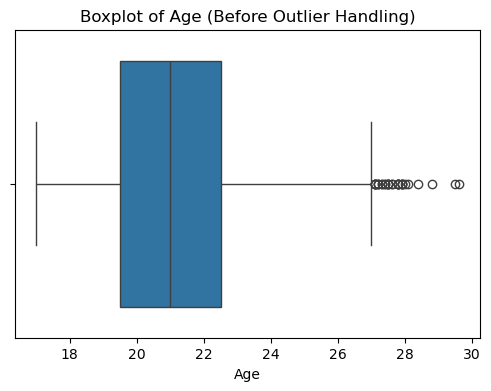

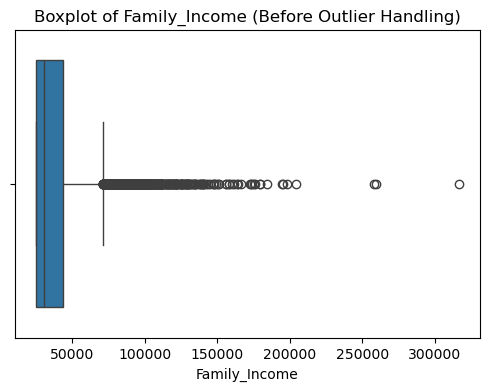

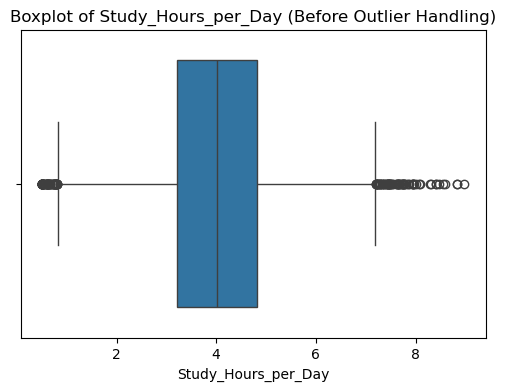

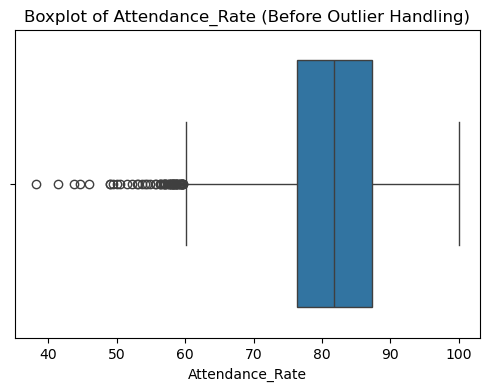

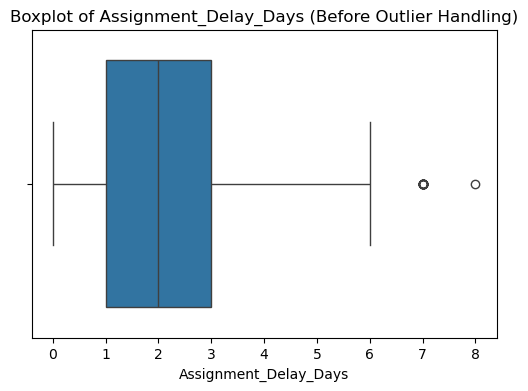

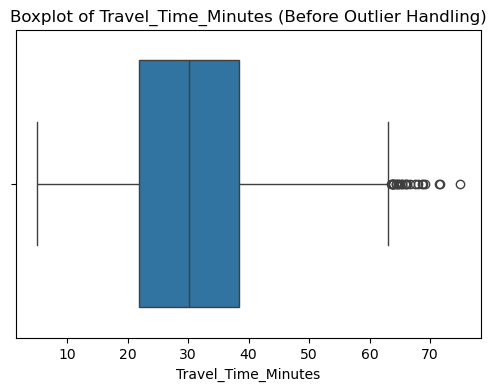


Column: Age
Q1 = 19.5
Q3 = 22.5
IQR = 3.0
Lower bound = 15.0
Upper bound = 27.0
Number of outliers = 33

Column: Family_Income
Q1 = 25000.0
Q3 = 43341.0
IQR = 18341.0
Lower bound = -2511.5
Upper bound = 70852.5
Number of outliers = 685

Column: Study_Hours_per_Day
Q1 = 3.21
Q3 = 4.81
IQR = 1.5999999999999996
Lower bound = 0.8100000000000005
Upper bound = 7.209999999999999
Number of outliers = 130

Column: Attendance_Rate
Q1 = 76.375
Q3 = 87.4
IQR = 11.025000000000006
Lower bound = 59.83749999999999
Upper bound = 103.93750000000001
Number of outliers = 56

Column: Assignment_Delay_Days
Q1 = 1.0
Q3 = 3.0
IQR = 2.0
Lower bound = -2.0
Upper bound = 6.0
Number of outliers = 21

Column: Travel_Time_Minutes
Q1 = 21.8
Q3 = 38.4
IQR = 16.599999999999998
Lower bound = -3.099999999999998
Upper bound = 63.3
Number of outliers = 21


In [24]:
#Task 3: Detect and Handle Outliers using IQR

outlier_cols = [
    'Age',
    'Family_Income',
    'Study_Hours_per_Day',
    'Attendance_Rate',
    'Assignment_Delay_Days',
    'Travel_Time_Minutes'
]

# Show boxplots before outlier handling
for col in outlier_cols:
    if col in df_encoded.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df_encoded[col])
        plt.title(f'Boxplot of {col} (Before Outlier Handling)')
        plt.show()

# Detect outliers column by column using IQR
df_no_outliers = df_encoded.copy()

for col in outlier_cols:
    if col in df_no_outliers.columns:
        Q1 = df_no_outliers[col].quantile(0.25)
        Q3 = df_no_outliers[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df_no_outliers[(df_no_outliers[col] < lower) | (df_no_outliers[col] > upper)]

        print(f"\nColumn: {col}")
        print("Q1 =", Q1)
        print("Q3 =", Q3)
        print("IQR =", IQR)
        print("Lower bound =", lower)
        print("Upper bound =", upper)
        print("Number of outliers =", outliers.shape[0])

        # Remove outliers
        df_no_outliers = df_no_outliers[
            (df_no_outliers[col] >= lower) & (df_no_outliers[col] <= upper)
        ]



In [25]:
print("\nShape before removing outliers:", df_encoded.shape)
print("Shape after removing outliers:", df_no_outliers.shape)


Shape before removing outliers: (10000, 19)
Shape after removing outliers: (9054, 19)


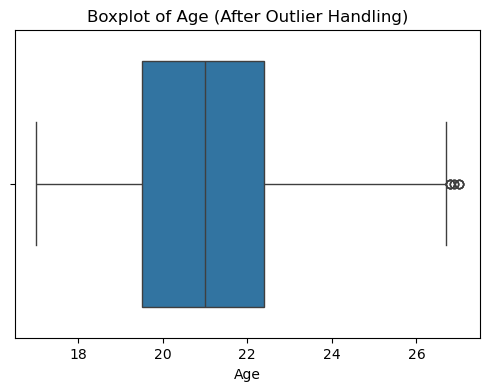

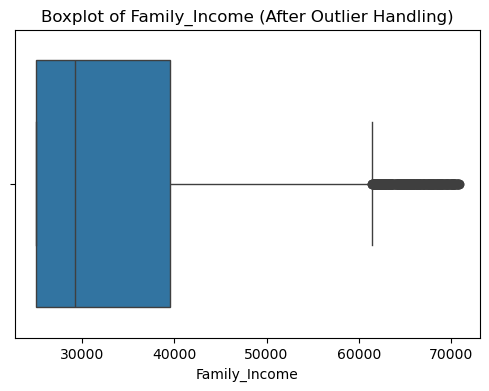

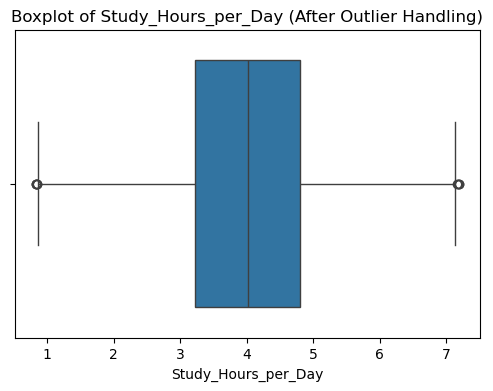

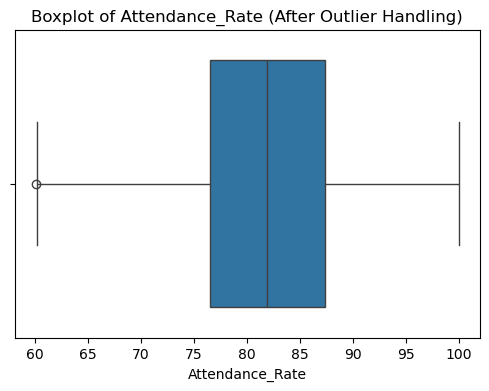

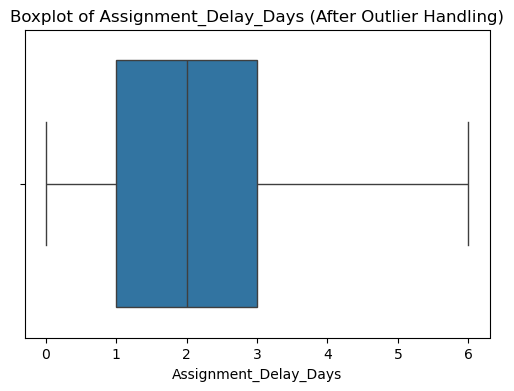

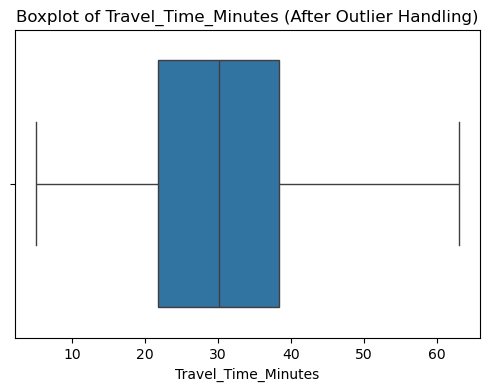

In [26]:
# Show boxplots after outlier handling
for col in outlier_cols:
    if col in df_no_outliers.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df_no_outliers[col])
        plt.title(f'Boxplot of {col} (After Outlier Handling)')
        plt.show()

In [27]:
#Task 4: Normalize Numerical Features
features_for_scaling = [
    'Age',
    'Family_Income',
    'Study_Hours_per_Day',
    'Attendance_Rate',
    'Assignment_Delay_Days',
    'Travel_Time_Minutes'
]

print("Original numerical features:")
display(df_no_outliers[features_for_scaling].head())

Original numerical features:


,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes
0,22.1,25000.000000,3.360000,86.1,2,20.4
1,20.7,25000.000000,4.300000,68.0,2,44.0
2,22.4,40183.000000,4.400000,70.9,0,48.9
3,24.4,38377.247474,4.014592,82.2,2,38.6
4,20.5,25319.000000,4.190000,75.7,1,23.0


In [28]:
# Min-Max Normalization
minmax_scaler = MinMaxScaler()
df_minmax = df_no_outliers.copy()
df_minmax[features_for_scaling] = minmax_scaler.fit_transform(df_minmax[features_for_scaling])

print("\nMin-Max normalized data:")
display(df_minmax[features_for_scaling].head())


Min-Max normalized data:


,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes
0,0.51,0.000000,0.397799,0.651629,0.333333,0.265517
1,0.37,0.000000,0.545597,0.197995,0.333333,0.672414
2,0.54,0.331167,0.561321,0.270677,0.000000,0.756897
3,0.74,0.291780,0.500722,0.553885,0.333333,0.579310
4,0.35,0.006958,0.528302,0.390977,0.166667,0.310345


In [29]:
# Z-Score Normalization
standard_scaler = StandardScaler()
df_zscore = df_no_outliers.copy()
df_zscore[features_for_scaling] = standard_scaler.fit_transform(df_zscore[features_for_scaling])

print("\nZ-score normalized data:")
display(df_zscore[features_for_scaling].head())


Z-score normalized data:


,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes
0,0.527826,-0.800311,-0.541102,0.524716,0.165120,-0.816736
1,-0.136799,-0.800311,0.240884,-1.739715,0.165120,1.180770
2,0.670246,0.514252,0.324075,-1.376906,-1.354955,1.595506
3,1.619710,0.357908,0.003453,0.036800,0.165120,0.723714
4,-0.231745,-0.772692,0.149375,-0.776394,-0.594918,-0.596671


Correlation matrix:


,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes
Age,1.000000,-0.016757,0.004740,0.010919,0.009381,-0.007322
Family_Income,-0.016757,1.000000,-0.005230,-0.004665,-0.000915,-0.001204
Study_Hours_per_Day,0.004740,-0.005230,1.000000,-0.018953,-0.004378,0.003823
Attendance_Rate,0.010919,-0.004665,-0.018953,1.000000,-0.010622,0.017655
Assignment_Delay_Days,0.009381,-0.000915,-0.004378,-0.010622,1.000000,0.004532
Travel_Time_Minutes,-0.007322,-0.001204,0.003823,0.017655,0.004532,1.000000


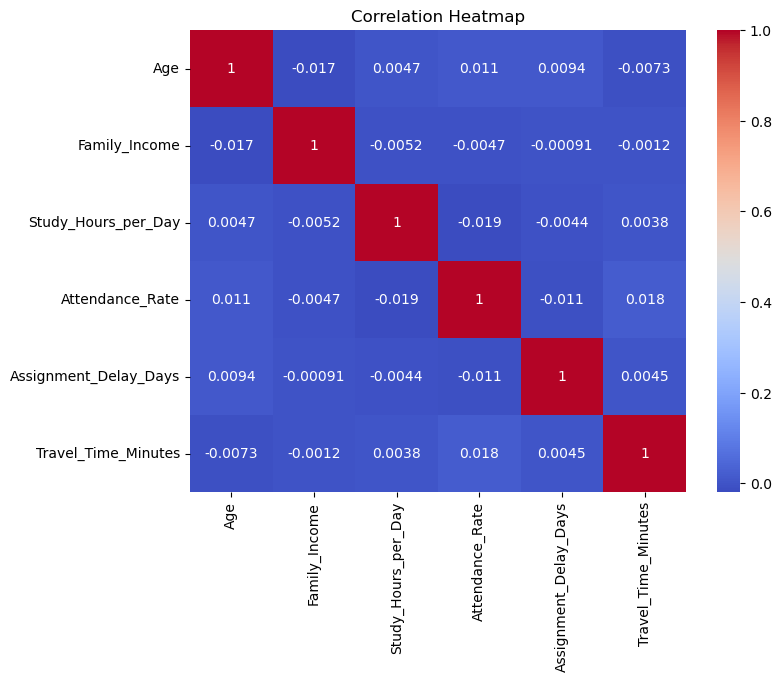

In [30]:
#Task 5: Apply PCA only if numerical features show correlation
corr_matrix = df_zscore[features_for_scaling].corr()

print("Correlation matrix:")
display(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [31]:
# Check strongest absolute correlation excluding diagonal
corr_no_diag = corr_matrix.abs().copy()
np.fill_diagonal(corr_no_diag.values, 0)
max_corr = corr_no_diag.max().max()

print("Maximum absolute correlation between different features:", max_corr)


Maximum absolute correlation between different features: 0.01895315042328051


In [33]:
# Apply PCA only if meaningful correlation exists
if max_corr >= 0.5:
    print("\nFeatures show enough correlation, so PCA will be applied.")

    X = df_zscore[features_for_scaling]

    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(X)

    pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2'])

    print("Explained Variance Ratio:")
    print(pca.explained_variance_ratio_)

    print("\nPCA Result:")
    display(pca_df.head())

    plt.figure(figsize=(6,4))
    plt.scatter(pca_df['PC1'], pca_df['PC2'])
    plt.title("PCA Projection")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()

else:
    print("\nFeatures do not show strong enough correlation.")
    print("So PCA is skipped.")


Features do not show strong enough correlation.
So PCA is skipped.
